# 피어 Levered Beta 검증 노트북

설계서 v4 §1.6 기준 — 아모레퍼시픽 POC (4사: 아모레퍼시픽 + LG생활건강 + 한국콜마 + 에이피알)

**단계**
1. 환경 점검 (.env, 패키지)
2. KRX API 단건 호출 smoke test (응답 구조 확인)
3. 전체 수집 + 회귀 실행
4. 시각화: 주간 종가, 산점도 + 회귀선, 잔차 플롯
5. 검증 요약: β_raw → β_adjusted, R², 경고 플래그
6. 팀원의 XBRL 결과와 합치는 예시 (Hamada Unlever 미리보기)

노트북은 `peer_beta/` 모듈을 import해서 사용합니다. 모듈 코드를 손대지 않고 셀 단위로 검증할 수 있습니다.

## 0. Path 셋업 — 노트북이 어디서 실행되든 모듈 import 가능하도록

In [1]:
import sys, os
from pathlib import Path

# 노트북 파일과 peer_beta/ 가 같은 폴더(VAR/)에 있다고 가정
PROJECT_DIR = Path.cwd()
if (PROJECT_DIR / 'peer_beta').exists():
    sys.path.insert(0, str(PROJECT_DIR))
else:
    # 상위 폴더 탐색
    for parent in PROJECT_DIR.parents:
        if (parent / 'peer_beta').exists():
            sys.path.insert(0, str(parent))
            PROJECT_DIR = parent
            break
print('PROJECT_DIR =', PROJECT_DIR)

PROJECT_DIR = c:\Users\Admin\Desktop\VAR


## 1. 환경 점검

In [2]:
from dotenv import load_dotenv
env_path = PROJECT_DIR / '.env'
loaded = load_dotenv(env_path)
print(f'.env loaded: {loaded}  (path={env_path})')
print(f"krxdata key set : {bool(os.getenv('krxdata'))}")
print(f"  prefix         : {os.getenv('krxdata', '')[:8]}...")

.env loaded: True  (path=c:\Users\Admin\Desktop\VAR\.env)
krxdata key set : True
  prefix         : 8EB11394...


In [3]:
# 필요 패키지 점검
import importlib
for pkg in ['requests', 'pandas', 'numpy', 'statsmodels', 'matplotlib', 'dotenv']:
    try:
        importlib.import_module(pkg if pkg != 'dotenv' else 'dotenv')
        print(f'  OK   {pkg}')
    except Exception as e:
        print(f'  MISS {pkg}: {e}')

  OK   requests
  OK   pandas
  OK   numpy
  OK   statsmodels
  OK   matplotlib
  OK   dotenv


## 2. KRX API smoke test

한 번 호출해서 응답 구조가 표준 KRX OpenAPI 포맷과 일치하는지 확인합니다.
혹시 키 이름이 다르면 `peer_beta/krx_client.py` 의 `_parse_stock_row` / `_parse_index_row` 만 손대면 됩니다.

In [4]:
import requests
headers = {'AUTH_KEY': os.getenv('krxdata')}

# 최근 평일 하나 (필요시 날짜 변경)
BAS_DD = '20260508'   # 금요일 예시

r = requests.get('https://data-dbg.krx.co.kr/svc/apis/sto/stk_bydd_trd',
                 headers=headers, params={'basDd': BAS_DD}, timeout=30)
print('status:', r.status_code)
data = r.json()
print('top-level keys:', list(data.keys()))
rows = data.get('OutBlock_1', [])
print(f'row count: {len(rows)}')
if rows:
    print('sample row keys:', list(rows[0].keys()))
    # 명세서 Spec 5: ISU_CD 는 12자리 표준코드(예: KR7090430005)
    # 단축코드(090430)와 비교하려면 [3:9] 슬라이싱이 필요.
    def _short(code):
        s = str(code).strip()
        return s[3:9] if len(s) == 12 and s.upper().startswith('KR') else s.zfill(6)
    print('아모레퍼시픽(090430) row:')
    match = [x for x in rows if _short(x.get('ISU_CD','')) == '090430'
                                 or x.get('ISU_SRT_CD') == '090430']
    print(match)

status: 200
top-level keys: ['OutBlock_1']
row count: 948
sample row keys: ['BAS_DD', 'ISU_CD', 'ISU_NM', 'MKT_NM', 'SECT_TP_NM', 'TDD_CLSPRC', 'CMPPREVDD_PRC', 'FLUC_RT', 'TDD_OPNPRC', 'TDD_HGPRC', 'TDD_LWPRC', 'ACC_TRDVOL', 'ACC_TRDVAL', 'MKTCAP', 'LIST_SHRS']
아모레퍼시픽(090430) row:
[{'BAS_DD': '20260508', 'ISU_CD': '090430', 'ISU_NM': '아모레퍼시픽', 'MKT_NM': 'KOSPI', 'SECT_TP_NM': '', 'TDD_CLSPRC': '129400', 'CMPPREVDD_PRC': '-500', 'FLUC_RT': '-0.38', 'TDD_OPNPRC': '131200', 'TDD_HGPRC': '131400', 'TDD_LWPRC': '128000', 'ACC_TRDVOL': '297016', 'ACC_TRDVAL': '38353675300', 'MKTCAP': '7568963014600', 'LIST_SHRS': '58492759'}]


In [5]:
# 같은 날 KOSPI 지수
r = requests.get('https://data-dbg.krx.co.kr/svc/apis/idx/kospi_dd_trd',
                 headers=headers, params={'basDd': BAS_DD}, timeout=30)
print('status:', r.status_code)
data = r.json()
rows = data.get('OutBlock_1', [])
print(f'row count: {len(rows)}')
if rows:
    print('sample row keys:', list(rows[0].keys()))
    print('코스피 지수 row:')
    print([r for r in rows if r.get('IDX_NM') == '코스피'])

status: 200
row count: 51
sample row keys: ['BAS_DD', 'IDX_CLSS', 'IDX_NM', 'CLSPRC_IDX', 'CMPPREVDD_IDX', 'FLUC_RT', 'OPNPRC_IDX', 'HGPRC_IDX', 'LWPRC_IDX', 'ACC_TRDVOL', 'ACC_TRDVAL', 'MKTCAP']
코스피 지수 row:
[{'BAS_DD': '20260508', 'IDX_CLSS': 'KOSPI', 'IDX_NM': '코스피', 'CLSPRC_IDX': '7498.00', 'CMPPREVDD_IDX': '7.95', 'FLUC_RT': '0.11', 'OPNPRC_IDX': '7353.94', 'HGPRC_IDX': '7511.01', 'LWPRC_IDX': '7318.96', 'ACC_TRDVOL': '522179069', 'ACC_TRDVAL': '40790547036934', 'MKTCAP': '6142448381397920'}]


## 3. 전체 수집 + 회귀 실행

약 100여 일자에 대해 API를 호출합니다 (시장별 1회 + 종목별 1회씩). 캐시가 작동하므로 같은 날짜 재실행은 빠릅니다.

In [6]:
from peer_beta.run_beta import run

# eval_date=None 이면 오늘. 특정일로 고정하려면 'YYYY-MM-DD' 로 전달.
result = run(eval_date=None, save_json=True, save_csv=True, verbose=True)

[T=2026-05-14] lookback=2년, 금요일 후보 105개
피어/타겟 4사: 아모레퍼시픽(090430/KOSPI), LG생활건강(051900/KOSPI), 한국콜마(161890/KOSPI), 에이피알(278470/KOSPI)

[1/3] 시장 지수 수집...
  - KOSPI: 관측 105건

[2/3] 종목 주간 종가 수집...
  - 아모레퍼시픽(090430): 관측 105건
  - LG생활건강(051900): 관측 105건
  - 한국콜마(161890): 관측 105건
  - 에이피알(278470): 관측 105건

[3/3] OLS 회귀 + Blume 조정...
  - 아모레퍼시픽: β_raw=0.4407, β_adj=0.6253, R²=0.052, n=104, warn=['low_r_squared', 'outliers', 'short_listing']
  - LG생활건강: β_raw=0.3998, β_adj=0.5979, R²=0.144, n=104, warn=['short_listing']
  - 한국콜마: β_raw=0.3363, β_adj=0.5553, R²=0.051, n=104, warn=['low_r_squared', 'short_listing']
  - 에이피알: β_raw=1.0743, β_adj=1.0498, R²=0.037, n=104, warn=['low_r_squared', 'outliers', 'short_listing']

[캐시] 조회 545회 = HIT 315 / MISS(API호출) 230 (빈응답 미저장 20) → HIT rate 57.8%

JSON 저장: C:\Users\Admin\Desktop\VAR\peer_beta\results\peer_beta_20260514.json
CSV 저장 : weekly_prices_20260514.csv, weekly_returns_20260514.csv


### 3-A. 이상치 처리 방식 3종 비교 — KRX 공시 베타와 정합성 측정

**일반 투자자 대상 권장** = `winsorize` (디폴트). 표본 N 유지하면서 이상치 영향만 ±3σ로 약화.

| 방식 | 설명 | 표본 |
| --- | --- | --- |
| `none` | 설계서 §1.6 원안. 이상치 그대로 포함 | N |
| `drop` | \|z\|>4 행 제거 후 재회귀 | N − k |
| `winsorize` | \|잔차\|>3σ 행을 ±3σ로 자르고 재회귀 | **N 유지** |


In [ ]:
# 3가지 이상치 처리 모드로 베타 계산 후 KRX 공시값과 비교
import pandas as pd
from peer_beta.run_beta import run

EVAL_DATE = result['eval_date']

# KRX 공시 2년 베타 (2026-05-08 기준)
krx_official = {
    '아모레퍼시픽': 0.397387,
    'LG생활건강':   0.393045,
    '한국콜마':     0.325460,
    '에이피알':     0.745769,
}

mode_results = {}
for mode in ['none', 'drop', 'winsorize']:
    print(f'\n── outlier_handling={mode!r} ──')
    r = run(eval_date=EVAL_DATE, outlier_handling=mode,
            save_json=False, save_csv=False, verbose=False)
    mode_results[mode] = r['peers']
    for name, info in r['peers'].items():
        extra = ''
        if info['outlier_handling'] == 'drop' and info['n_outliers_dropped'] > 0:
            extra = f"  dropped={info['n_outliers_dropped']}"
        if info['outlier_handling'] == 'winsorize' and info.get('n_outliers_winsorized', 0) > 0:
            extra = f"  winsorized={info['n_outliers_winsorized']}(±{info.get('winsorize_k')}σ)"
        print(f"  {name:8s}  β_raw={info['beta_raw']:+.4f}  β_adj={info['beta_adjusted']:+.4f}  "
              f"R²={info['r_squared']:.3f}  n={info['n_weeks_used']}{extra}")

# 비교 표 — 각 모드의 β_raw 와 KRX 절대오차
rows = []
for name, krx_b in krx_official.items():
    row = {'회사': name, 'KRX β_raw': round(krx_b, 6)}
    for mode in ['none', 'drop', 'winsorize']:
        b = mode_results[mode].get(name, {}).get('beta_raw')
        if b is None:
            row[mode] = None; row[f'Δ {mode}'] = None
        else:
            row[mode] = round(b, 4)
            row[f'Δ {mode}'] = round(b - krx_b, 4)
    rows.append(row)
compare = pd.DataFrame(rows)

# 합산 절대오차 (낮을수록 KRX와 정합)
sums = {mode: compare[f'Δ {mode}'].abs().sum() for mode in ['none', 'drop', 'winsorize']}
winner = min(sums, key=sums.get)
print(f'\n[KRX 4사 절대오차 합산] none={sums["none"]:.4f}  '
      f'drop={sums["drop"]:.4f}  winsorize={sums["winsorize"]:.4f}')
print(f'→ 가장 KRX에 가까운 모드: {winner!r}')
compare


In [7]:
import pandas as pd

# 피어별 베타 요약 테이블
rows = []
for name, r in result['peers'].items():
    rows.append({
        '회사명':     name,
        '종목코드':    r['ticker'],
        '시장':       r['market'],
        'n_weeks':    r['n_weeks_used'],
        'β_raw':      round(r['beta_raw'], 4),
        'β_adj':      round(r['beta_adjusted'], 4),
        'α':          round(r['alpha'], 6),
        'R²':         round(r['r_squared'], 4),
        'SE(β)':      round(r['std_err_beta'], 4),
        '상장(년)':    r['listing_years'],
        '결측주':      r['missing_weeks'],
        '경고':       ', '.join(r['warnings']) if r['warnings'] else '-',
    })
summary = pd.DataFrame(rows)
summary

,회사명,종목코드,시장,n_weeks,β_raw,β_adj,α,R²,SE(β),상장(년),결측주,경고
0,아모레퍼시픽,090430,KOSPI,104,0.4407,0.6253,-0.006954,0.0521,0.1862,1.974,0,"low_r_squared, outliers, short_listing"
1,LG생활건강,051900,KOSPI,104,0.3998,0.5979,-0.008941,0.1437,0.0966,1.974,0,short_listing
2,한국콜마,161890,KOSPI,104,0.3363,0.5553,0.001808,0.0505,0.1443,1.974,0,"low_r_squared, short_listing"
3,에이피알,278470,KOSPI,104,1.0743,1.0498,-0.008141,0.0371,0.5418,1.974,0,"low_r_squared, outliers, short_listing"


## 4. 시각화

In [8]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd

# 한글 폰트 (Windows 기준 'Malgun Gothic')
matplotlib.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

from peer_beta.beta_calculator import align_weekly_returns

eval_d = result['eval_date']
indices = result['indices']
stocks  = result['stocks_weekly']
peers   = result['peers']

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

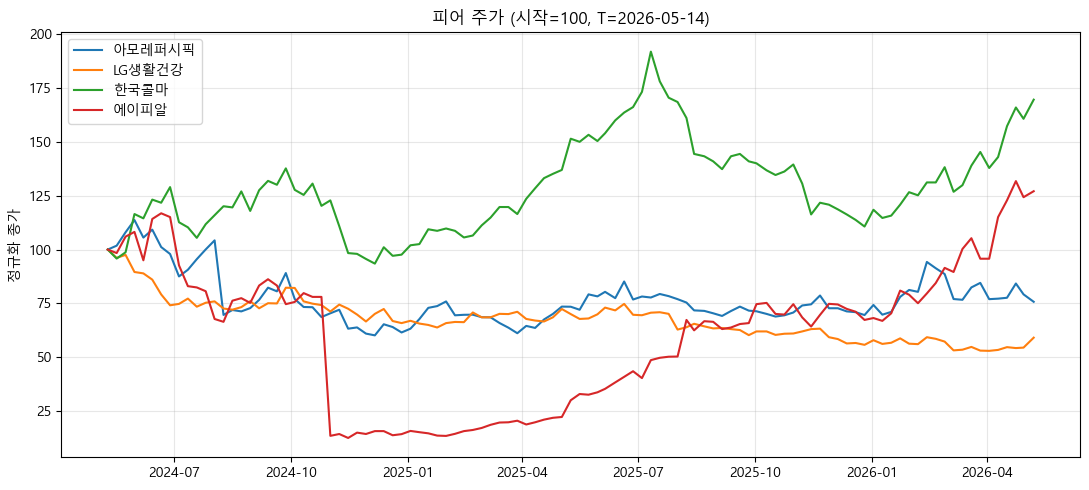

In [9]:
# 4-1) 주간 종가 시계열 (정규화 100 기준)
fig, ax = plt.subplots(figsize=(11, 5))
for name, pts in stocks.items():
    if not pts:
        continue
    df = pd.DataFrame(pts)
    df['actual_date'] = pd.to_datetime(df['actual_date'])
    df = df.sort_values('actual_date')
    norm = df['close'] / df['close'].iloc[0] * 100
    ax.plot(df['actual_date'], norm, label=name)
ax.set_title(f'피어 주가 (시작=100, T={eval_d})')
ax.set_ylabel('정규화 종가')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

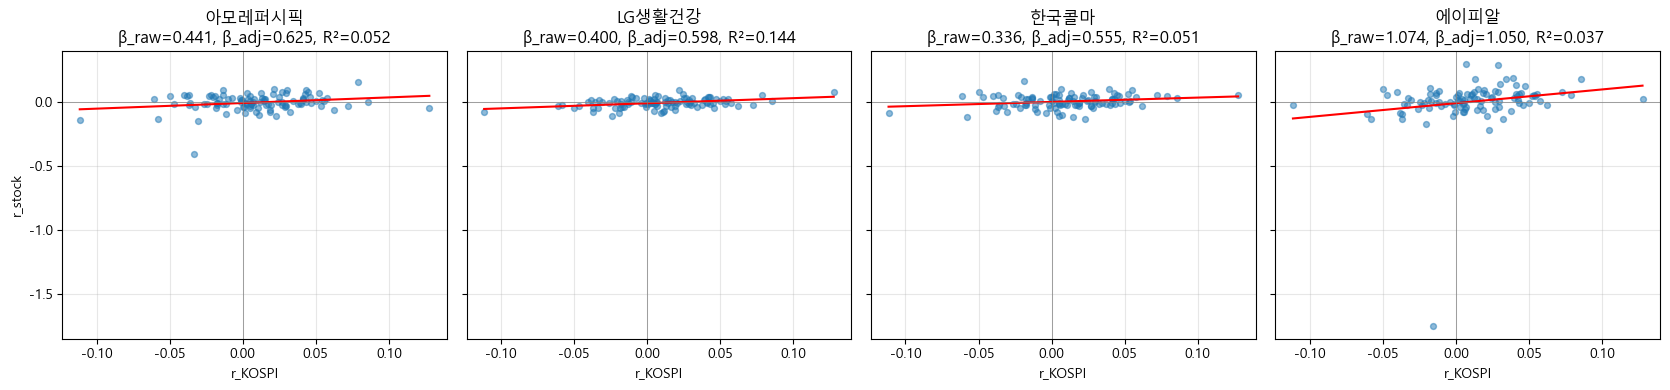

In [10]:
# 4-2) 산점도 + 회귀선 (각 피어)
n_peers = len(peers)
fig, axes = plt.subplots(1, n_peers, figsize=(4.2 * n_peers, 4), sharey=True)
if n_peers == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, peers.items()):
    market = r['market']
    idx_pts = indices.get(market, [])
    stk_pts = stocks.get(name, [])
    ret = align_weekly_returns(stk_pts, idx_pts)
    if ret.empty:
        ax.set_title(f'{name}: 데이터 없음'); continue
    x = ret['r_index'].values
    y = ret['r_stock'].values
    ax.scatter(x, y, alpha=0.5, s=18)
    # 회귀선
    beta = r['beta_raw']; alpha = r['alpha']
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, alpha + beta * xs, color='red', lw=1.5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel(f'r_{market}')
    ax.set_title(f"{name}\nβ_raw={beta:.3f}, β_adj={r['beta_adjusted']:.3f}, R²={r['r_squared']:.3f}")
    ax.grid(alpha=0.3)
axes[0].set_ylabel('r_stock')
plt.tight_layout(); plt.show()

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

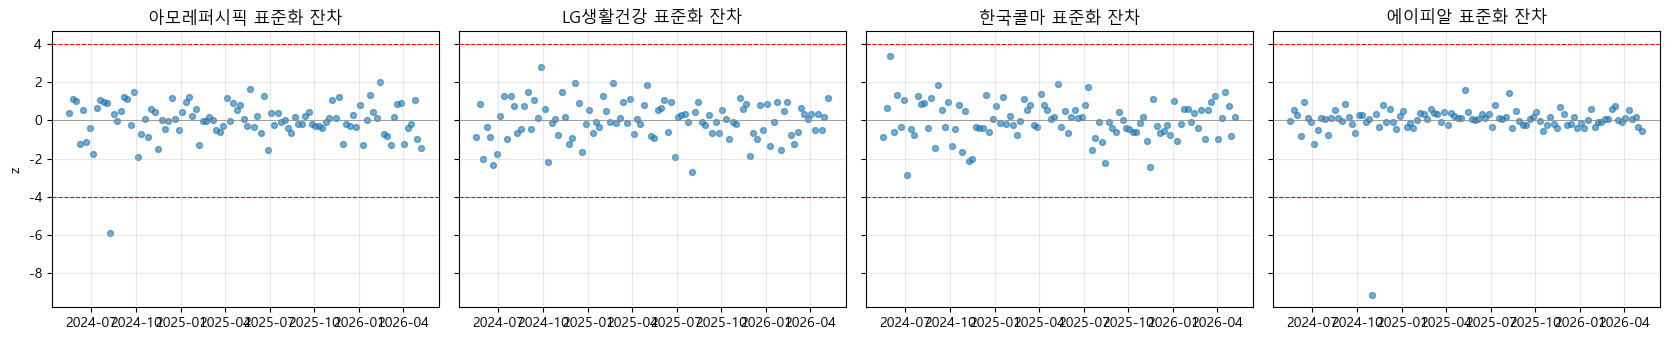

In [11]:
# 4-3) 잔차 플롯 + |z|>4 표시
import statsmodels.api as sm

fig, axes = plt.subplots(1, n_peers, figsize=(4.2 * n_peers, 3.5), sharey=True)
if n_peers == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, peers.items()):
    idx_pts = indices.get(r['market'], [])
    stk_pts = stocks.get(name, [])
    ret = align_weekly_returns(stk_pts, idx_pts)
    if ret.empty:
        ax.set_title(f'{name}: 데이터 없음'); continue
    y = ret['r_stock'].values
    X = sm.add_constant(ret['r_index'].values)
    fit = sm.OLS(y, X).fit()
    resid = pd.Series(fit.resid, index=ret.index)
    z = (resid - resid.mean()) / (resid.std(ddof=1) or 1.0)
    ax.scatter(z.index, z.values, alpha=0.6, s=18)
    ax.axhline( 4, color='red', lw=0.8, ls='--')
    ax.axhline(-4, color='red', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_title(f'{name} 표준화 잔차')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('z')
plt.tight_layout(); plt.show()

## 5. 검증 요약

In [12]:
print('eval_date  :', result['eval_date'])
print('금요일 후보 수 :', result['fridays_requested'])
print('Blume α   :', result['config']['blume_alpha'])
print('R² 임계   :', result['config']['validation']['r_squared_min'])
print()
for name, r in result['peers'].items():
    print(f"  {name:>10s}  β_raw={r['beta_raw']:+.4f}  β_adj={r['beta_adjusted']:+.4f}  "
          f"R²={r['r_squared']:.3f}  n={r['n_weeks_used']:3d}  warn={r['warnings'] or '-'}")

eval_date  : 2026-05-14
금요일 후보 수 : 105
Blume α   : 0.67
R² 임계   : 0.1

      아모레퍼시픽  β_raw=+0.4407  β_adj=+0.6253  R²=0.052  n=104  warn=['low_r_squared', 'outliers', 'short_listing']
      LG생활건강  β_raw=+0.3998  β_adj=+0.5979  R²=0.144  n=104  warn=['short_listing']
        한국콜마  β_raw=+0.3363  β_adj=+0.5553  R²=0.051  n=104  warn=['low_r_squared', 'short_listing']
        에이피알  β_raw=+1.0743  β_adj=+1.0498  R²=0.037  n=104  warn=['low_r_squared', 'outliers', 'short_listing']


## 6. 팀원 결과와 합치는 예시 — Hamada Unlever

팀원이 XBRL에서 추출한 피어 자본구조 데이터(`peers_capital_structure.json` 또는 dict)와 합쳐서
`βU = βL / [1 + (1-t) × D/E]` 를 계산할 수 있습니다. **본 노트북은 베타까지만**, Unlever 이후 단계는
팀 통합 단계에서 결합합니다. 아래는 더미 데이터로 흐름만 보여줍니다.

In [ ]:
# DUMMY: 팀원이 채워줄 자본구조 - 실제로는 팀원의 산출물 JSON에서 로드.
dummy_cap_struct = {
    '아모레퍼시픽': {'D': 500_000, 'E': 4_500_000, 'tax_rate': 0.242},
    'LG생활건강':   {'D': 800_000, 'E': 5_500_000, 'tax_rate': 0.242},
    '한국콜마':     {'D': 600_000, 'E': 1_200_000, 'tax_rate': 0.242},
    '에이피알':     {'D':  50_000, 'E': 1_800_000, 'tax_rate': 0.242},
}

rows = []
for name, r in result['peers'].items():
    if name not in dummy_cap_struct or pd.isna(r['beta_adjusted']):
        continue
    cap = dummy_cap_struct[name]
    de  = cap['D'] / cap['E']
    bL  = r['beta_adjusted']
    bU  = bL / (1 + (1 - cap['tax_rate']) * de)
    rows.append({'회사': name, 'β_L (adj)': round(bL, 3),
                 'D/E': round(de, 3), 'tax': cap['tax_rate'],
                 'β_U': round(bU, 3)})
pd.DataFrame(rows)

---
**산출물 위치**
- `peer_beta/results/peer_beta_YYYYMMDD.json` — 메인 결과 (팀원 모듈에서 그대로 import 가능)
- `peer_beta/data/processed/weekly_prices_YYYYMMDD.csv` — 주간 종가 패널
- `peer_beta/data/processed/weekly_returns_YYYYMMDD.csv` — 주간 수익률 패널
- `peer_beta/data/raw/*.json` — KRX 일자별 raw 캐시 (재호출 방지)